In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [19]:
# Import All Dataset

import pickle

with open("allDataset.pkl", "rb") as f:
  allDataset = pickle.load(f)

In [20]:
print(allDataset.shape)
print(allDataset.keys())

(6894, 36)
Index(['background_father', 'background_mother', 'age', 'gender', 'smoke',
       'drink', 'skin_cancer_history', 'cancer_history', 'pesticide',
       'biopsed', 'grew', 'hurt', 'bleed', 'itch', 'elevation', 'changed',
       'diameter_1', 'diameter_2', 'has_sewage_system', 'has_piped_water',
       'race', 'img_id', 'diagnostic', 'region_ARM', 'region_BACK',
       'region_CHEST', 'region_EAR', 'region_FACE', 'region_FOOT',
       'region_FOREARM', 'region_HAND', 'region_LIP', 'region_NECK',
       'region_NOSE', 'region_SCALP', 'region_THIGH'],
      dtype='object')


In [21]:
# Get Imgs + Labels

imgs = []
labels = []

for i in range(len(allDataset)):
  image = cv2.imread(allDataset["img_id"][i])
  image_resize = cv2.resize(image, (128, 128))
  imgs.append(image_resize)
  labels.append(allDataset["diagnostic"][i])

In [22]:
# Split The Data

from sklearn.model_selection import train_test_split
tempImgs = np.array(imgs)
tempLabels = np.array(labels)

x_train, x_test, y_train, y_test = train_test_split(tempImgs, tempLabels, test_size = 0.3, random_state = 42)

In [23]:
# Images Normalization

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [24]:
# Labels OneHotEncoding

from sklearn.preprocessing import LabelEncoder

labelEncoder = LabelEncoder()
y_train = labelEncoder.fit_transform(y_train)
y_test = labelEncoder.transform(y_test)
print(labelEncoder.classes_)

orderLabels = labelEncoder.classes_

print(labelEncoder.classes_[0])

['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']
ACK


(4825, 128, 128, 3)
(2069, 128, 128, 3)


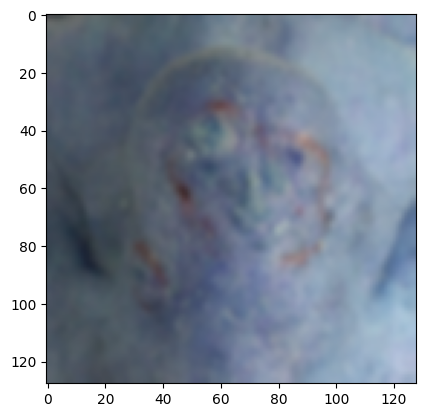

In [25]:
print(x_train.shape)
print(x_test.shape)

plt.imshow(x_train[0])

In [26]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

cnn = Sequential()

In [27]:
cnn.add(layers.Conv2D(filters = 32,
                      kernel_size = 3, strides = 1, padding = "same",
                      activation = "relu", input_shape = (128, 128, 3)))
cnn.add(layers.MaxPool2D(pool_size = (2, 2), strides = (2, 2), padding = "valid"))

cnn.add(layers.Conv2D(64, (3, 3), activation = "relu"))
cnn.add(layers.MaxPool2D((2, 2)))

cnn.add(layers.Conv2D(128, (3, 3), activation = "relu"))
cnn.add(layers.MaxPool2D((2, 2)))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(units = 128, activation = "relu"))
cnn.add(layers.Dense(units = 64, activation = "relu"))
cnn.add(layers.Dense(units = 6, activation = "softmax"))

d:\2. My Learning\03. Data Science\02. Learn\02. NTI-Huawei\16. Final Project\Project\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
cnn.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

checkPoint = ModelCheckpoint("best_model.keras", monitor = "val_accuracy")
earlyStopping = EarlyStopping(monitor = "val_accuracy", patience = 5)

hist = cnn.fit(x_train, y_train, epochs = 50, validation_split = 0.2, batch_size = 128, callbacks = [checkPoint, earlyStopping])

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.3759 - loss: 1.5102 - val_accuracy: 0.4187 - val_loss: 1.4249
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4868 - loss: 1.3800 - val_accuracy: 0.5223 - val_loss: 1.3070
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5132 - loss: 1.2692 - val_accuracy: 0.5223 - val_loss: 1.2540
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5484 - loss: 1.2233 - val_accuracy: 0.5710 - val_loss: 1.1883
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5790 - loss: 1.1448 - val_accuracy: 0.5855 - val_loss: 1.1199
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5772 - loss: 1.1369 - val_accuracy: 0.5990 - val_loss: 1.0749
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5891 - loss: 1.0827 - val_accuracy: 0.6062 - val_loss: 1.0412
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6109 - loss: 1.0486 - val_accuracy: 0.6176 - val_loss:

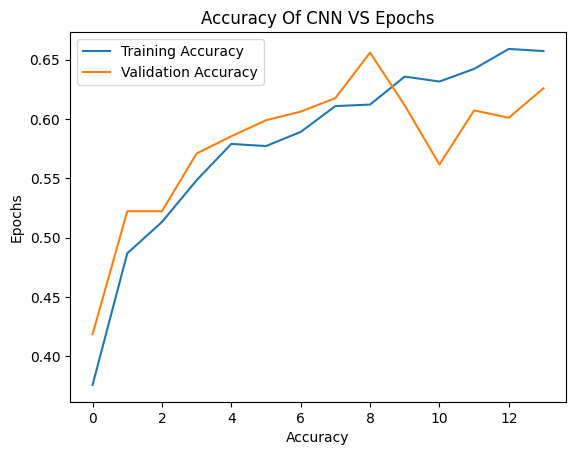

In [29]:
# Accuracy Visualization

plt.plot(hist.history["accuracy"], label = "Training Accuracy")
plt.plot(hist.history["val_accuracy"], label = "Validation Accuracy")

plt.title("Accuracy Of CNN VS Epochs")
plt.xlabel("Accuracy")
plt.ylabel("Epochs")

plt.legend()
plt.show()

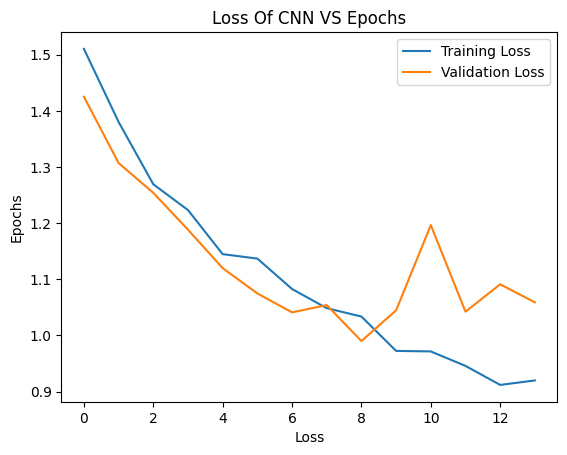

In [30]:
# Loss Visualization

plt.plot(hist.history["loss"], label = "Training Loss")
plt.plot(hist.history["val_loss"], label = "Validation Loss")

plt.title("Loss Of CNN VS Epochs")
plt.xlabel("Loss")
plt.ylabel("Epochs")

plt.legend()
plt.show()

In [31]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,939,860 (37.92 MB)

 Trainable params: 3,313,286 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,626,574 (25.28 MB)

In [32]:
# Evaluate The model

model_loss, model_accuracy = cnn.evaluate(x_test, y_test)

print(f"Model Loss {model_loss}")
print(f"Model Accuracy {model_accuracy}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.5892 - loss: 1.1348
Model Loss 1.134789228439331
Model Accuracy 0.5891734957695007


In [33]:
# Save Model

cnn.save("cnn_model.keras")

In [34]:
# Export Labels' Dictionary, Train, Test

import pickle

with open("orderLabels.pkl", "wb") as f:
  pickle.dump(orderLabels, f)

with open("x_train_cnn.pkl", "wb") as f:
  pickle.dump(x_train, f)

with open("y_train_cnn.pkl", "wb") as f:
  pickle.dump(y_train, f)

with open("x_test_cnn.pkl", "wb") as f:
  pickle.dump(x_test, f)

with open("y_test_cnn.pkl", "wb") as f:
  pickle.dump(y_test, f)